In [62]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy.ndimage as ndi
from scipy import interpolate
from skimage.transform import radon

In [63]:
annotated_folder_path = "./data/annotated/"
images_folder_path = "./data/images/images/"

images_folder = Path(images_folder_path)
annotated_folder = Path(annotated_folder_path)

images, class_labels, wafer_maps, dots, defect_masks = [], [], [], [], []

for image_path in sorted(images_folder.iterdir()):
    image = Image.open(image_path)

    width, height = image.size

    image_np = np.array(image)
    image_bw_np = image_np[:, :, 0] / image_np.max()
    images.append(image_bw_np)

    black_threshold = 0.5
    black_mask = image_bw_np < black_threshold  # True where black

    # Per-pixel radius map so we can drop the wafer outline (also dark) before labeling
    center_x, center_y = width / 2.0, height / 2.0
    yy, xx = np.indices((height, width))
    radius_map = np.sqrt((xx - center_x) ** 2 + (yy - center_y) ** 2)

    # The outline sits at the largest dark radius
    wafer_radius = radius_map[black_mask].max()
    interior_mask = radius_map < 0.98 * wafer_radius

    # Full-resolution defect field: dark pixels inside the wafer, outline removed
    dots_mask = black_mask & interior_mask
    defect_masks.append(dots_mask)

    # Label connected blobs so that each blob of touching dark pixels is one defect dot
    labels, num_blobs = ndi.label(dots_mask)

    # Drop single-pixel JPEG speckle, then take one centroid per remaining blob
    component_sizes = np.bincount(labels.ravel())
    min_dot_pixels = 2
    keep_ids = [
        i for i in range(1, num_blobs + 1) if component_sizes[i] >= min_dot_pixels
    ]

    centroids = np.array(ndi.center_of_mass(dots_mask, labels, keep_ids))
    dot_ys, dot_xs = centroids[:, 0], centroids[:, 1]

    dots.append((dot_ys, dot_xs))

    # Build a wafer bin map: a coarse die grid (each cell spans ~10 px of the 640 px image)
    grid_resolution = 64
    wafer_map = np.zeros((grid_resolution, grid_resolution), dtype=int)

    # Map each centroid's pixel coords to its grid cell (clip guards the wafer edge)
    grid_cols = np.clip(
        (dot_xs / width * grid_resolution).astype(int), 0, grid_resolution - 1
    )
    grid_rows = np.clip(
        (dot_ys / height * grid_resolution).astype(int), 0, grid_resolution - 1
    )
    wafer_map[grid_rows, grid_cols] = 1

    wafer_maps.append(wafer_map)

for annotated_path in sorted(annotated_folder.iterdir()):
    if annotated_path.suffix == ".txt":
        with open(annotated_path, "r") as file:
            class_label = int(file.readline().split()[0])

        class_labels.append(class_label)

In [64]:
classes = [
    "center",
    "donut",
    "edge_ring",
    "edge_loc",
    "scratch",
    "random",
    "loc",
    "near_full",
    "swirl",
    "radial_spokes",
    "shot_grid",
    "crescent",
    "half_wafer",
    "wedge",
    "comet",
    "edge_scratch",
    "lift_pin",
    "bullseye",
    "gradient",
    "slip_lines",
    "double_ring",
]

In [65]:
def calculate_density(region: np.ndarray):
    return 100.0 * np.count_nonzero(region == 1) / region.size


def find_regions(wafer_map: np.ndarray):
    rows, cols = wafer_map.shape
    row_bounds = np.arange(0, rows, rows // 5)[:5]  # [0, r/5, 2r/5, 3r/5, 4r/5]
    col_bounds = np.arange(0, cols, cols // 5)[:5]

    top = wafer_map[: row_bounds[1], :]
    bottom = wafer_map[row_bounds[4] :, :]
    left = wafer_map[:, : col_bounds[1]]
    right = wafer_map[:, col_bounds[4] :]
    outer_bands = [top, right, bottom, left]

    inner_cells = [
        wafer_map[row_bounds[i] : row_bounds[i + 1], col_bounds[j] : col_bounds[j + 1]]
        for i in range(1, 4)
        for j in range(1, 4)
    ]

    return [calculate_density(region) for region in outer_bands + inner_cells]


feature_regions = [find_regions(wafer_map) for wafer_map in wafer_maps]

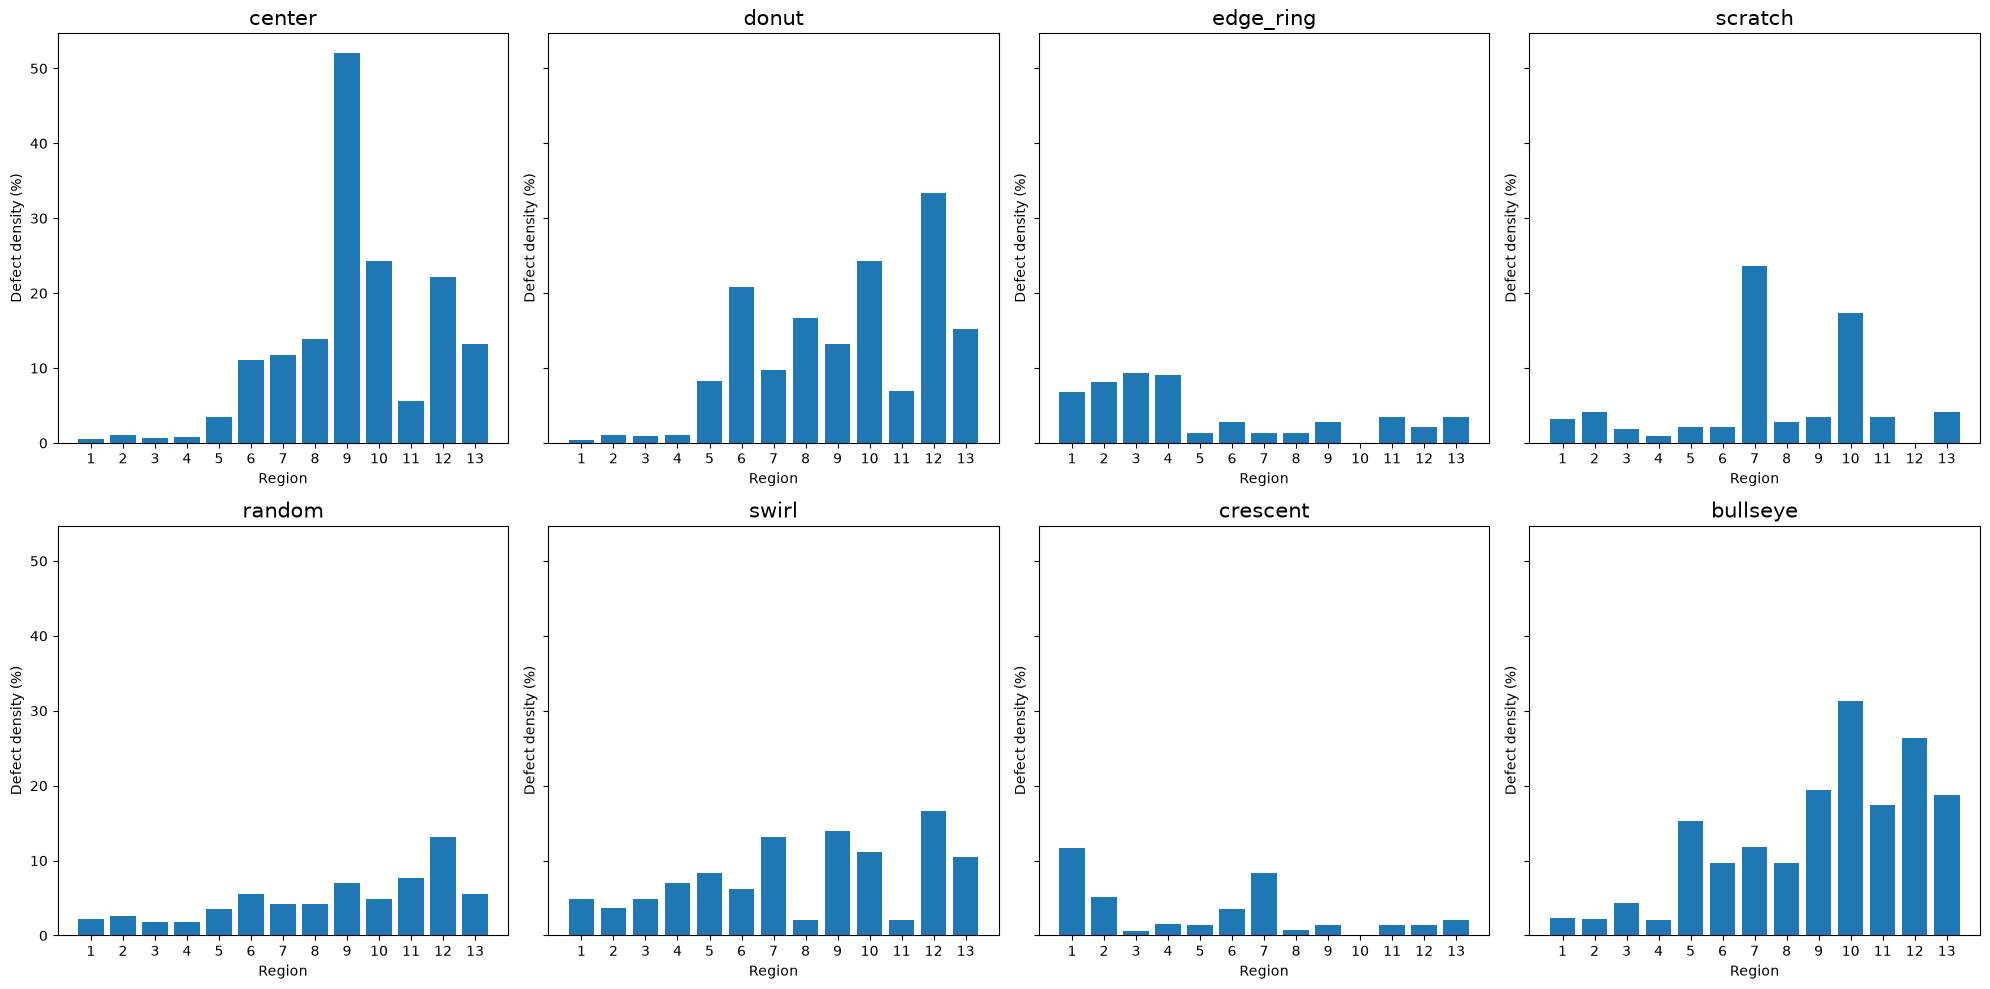

In [66]:
idxs = [9, 41, 71, 117, 123, 167, 238, 323]
region_ids = np.arange(1, 14)  # 13 regions

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharey=True)
ax = ax.ravel(order="C")
for i in range(8):
    ax[i].bar(region_ids, feature_regions[idxs[i]])
    ax[i].set_title(classes[class_labels[idxs[i]]], fontsize=15)
    ax[i].set_xticks(region_ids)
    ax[i].set_xlabel("Region")
    ax[i].set_ylabel("Defect density (%)")

plt.tight_layout()
plt.show()

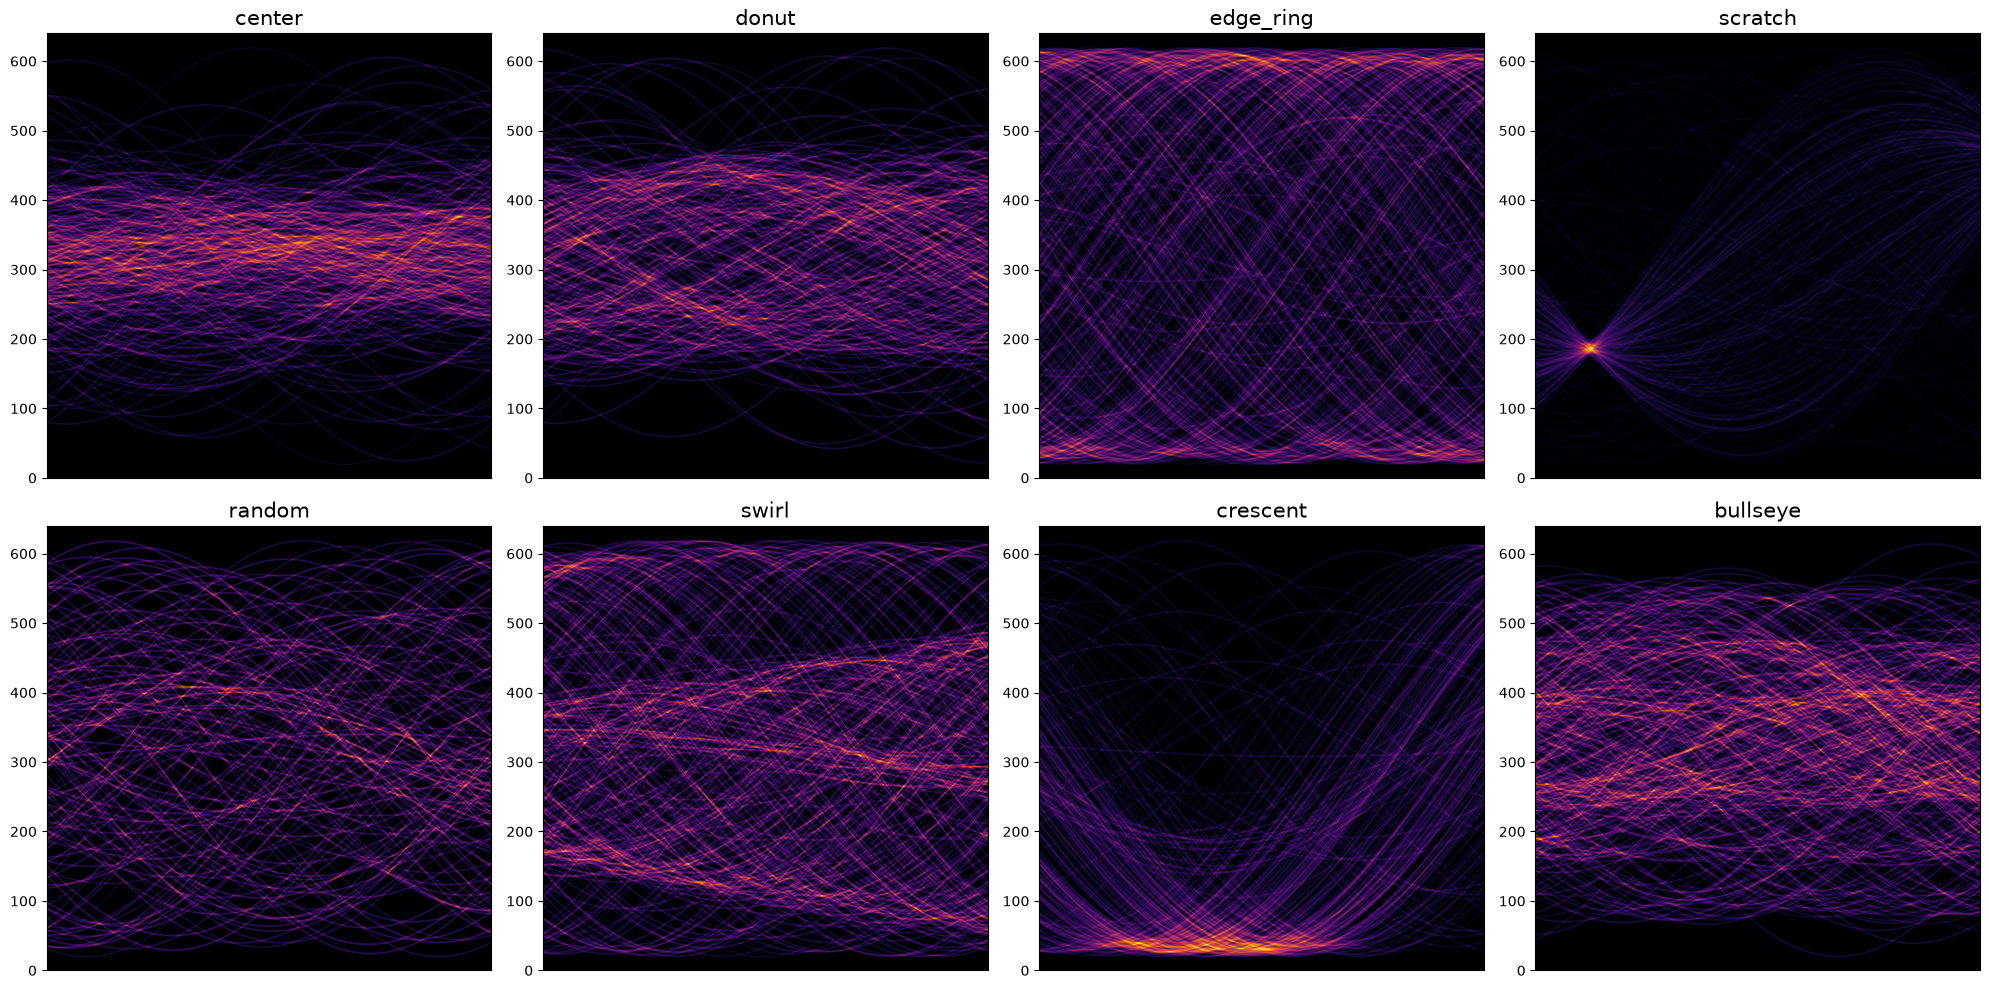

In [67]:
idxs = [9, 41, 71, 117, 123, 167, 238, 323]

# Sinograms of the full-resolution defect field
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
ax = ax.ravel(order="C")

for i in range(len(idxs)):
    mask = defect_masks[idxs[i]].astype(float)
    theta = np.linspace(0.0, 180.0, max(mask.shape), endpoint=False)
    sinogram = radon(mask, theta=theta)

    ax[i].imshow(
        sinogram,
        cmap="inferno",
        extent=(0, 180, 0, sinogram.shape[0]),
        aspect="auto",
    )
    ax[i].set_title(classes[class_labels[idxs[i]]], fontsize=15)
    ax[i].set_xticks([])

plt.tight_layout()
plt.show()

In [68]:
def radon_features(wafer_map: np.ndarray, n_points: int = 20):
    theta = np.linspace(0.0, 180.0, max(wafer_map.shape), endpoint=False)
    sinogram = radon(wafer_map.astype(float), theta=theta)  # shape: (positions, angles)

    projection_mean = sinogram.mean(axis=1)  # shape: (positions,)
    projection_std = sinogram.std(axis=1)  # shape: (positions,)

    positions = np.linspace(1, sinogram.shape[0], sinogram.shape[0])
    resampled = np.linspace(1, sinogram.shape[0], n_points)
    mean_profile = (
        interpolate.interp1d(positions, projection_mean, kind="cubic")(resampled)
        / 100.0
    )
    std_profile = (
        interpolate.interp1d(positions, projection_std, kind="cubic")(resampled) / 100.0
    )

    return mean_profile, std_profile


radon_mean_features, radon_std_features = [], []
for wafer_map in wafer_maps:
    mean_profile, std_profile = radon_features(wafer_map)
    radon_mean_features.append(mean_profile)
    radon_std_features.append(std_profile)

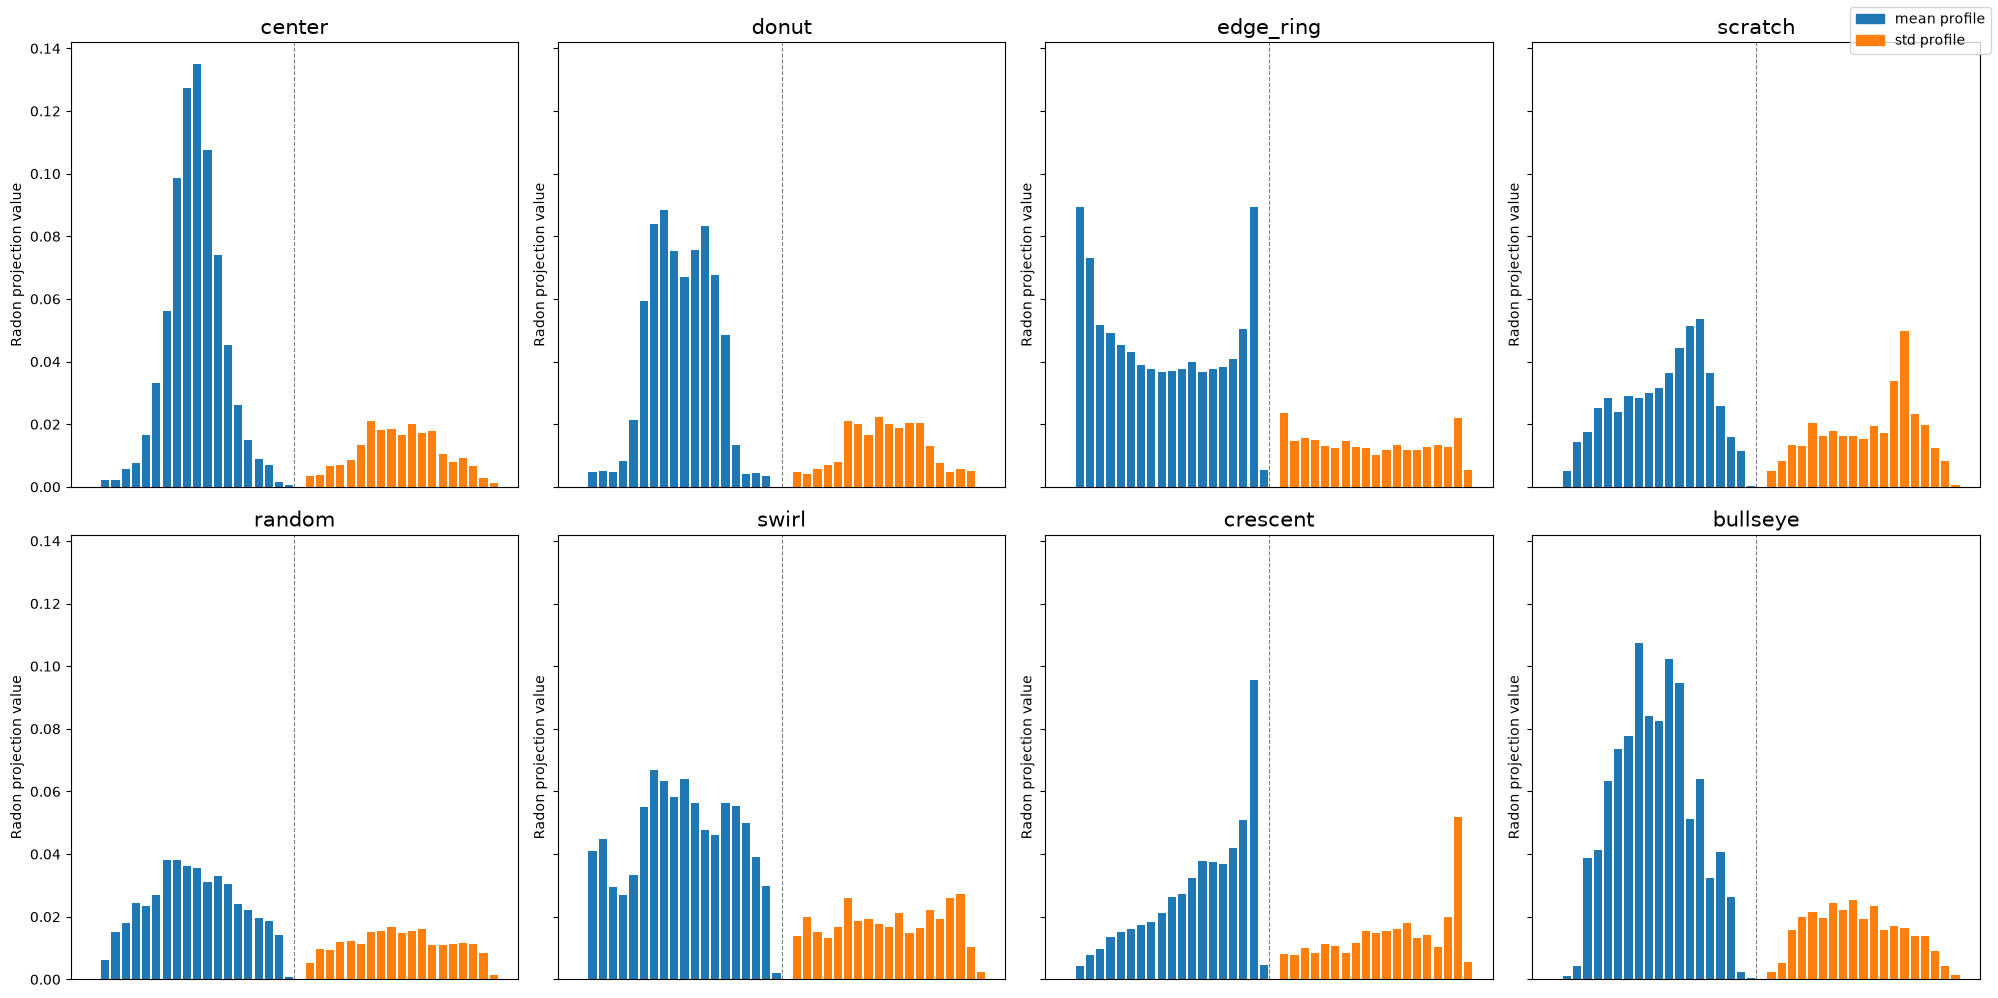

In [69]:
idxs = [9, 41, 71, 117, 123, 167, 238, 323]
n_points = radon_mean_features[0].size

# first half = mean profile, second half = std profile
feature_ids = np.arange(1, 2 * n_points + 1)
bar_colors = ["C0"] * n_points + ["C1"] * n_points

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharey=True)
ax = ax.ravel(order="C")

for i in range(len(idxs)):
    features = np.concatenate(
        [radon_mean_features[idxs[i]], radon_std_features[idxs[i]]]
    )
    ax[i].bar(feature_ids, features, color=bar_colors)

    # mean | std divider
    ax[i].axvline(n_points + 0.5, color="gray", linewidth=0.8, linestyle="--")

    ax[i].set_title(classes[class_labels[idxs[i]]], fontsize=15)
    ax[i].set_xticks([])
    ax[i].set_ylabel("Radon projection value")

fig.legend(
    handles=[
        Patch(color="C0", label="mean profile"),
        Patch(color="C1", label="std profile"),
    ],
    loc="upper right",
)

plt.tight_layout()
plt.show()